# 02 — Exploratory Data Analysis (EDA)
> Deep-dive into distributions, spatial patterns, ecoregion variation, and inter-feature relationships.

**Prerequisite:** Run `01_data_ingestion.ipynb` first.

## 0 · Colab Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !git clone https://github.com/YOUR_USERNAME/tree_carbon_ml.git 2>/dev/null || true
    %cd tree_carbon_ml
    !pip install -r requirements.txt -q
else:
    # If running locally inside the 'notebooks' folder, move up to the project root
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
# Add src to path
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f'Environment ready. Working directory is now: {os.getcwd()}')

Environment ready. Working directory is now: c:\Users\janan\Documents\ML_Project\Air_Quality_Predictor


## 1 · Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from visualization.plots import (
    plot_target_distribution, plot_missing_values,
    plot_spatial_distribution, plot_ecoregion_boxplot,
    plot_correlation_heatmap, FIGURES_DIR
)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
os.makedirs('outputs/figures', exist_ok=True)

TARGET = 'TPH.gs.dC.dN0.01'

df = pd.read_parquet('data/interim/01_raw_validated.parquet')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (110650, 23)


,PLT_CN,TPH.gs.dC.dN0.01,TPH.s.dC.dN0.01,TPH.g.dC.dN0.01,EXPN.ha,LAT,LON,EXPN.ha.TPH.gs.dC.dN0.01,EXPN.ha.TPH.s.dC.dN0.01,EXPN.ha.TPH.g.dC.dN0.01,...,STATECD,COUNTYCD,e3,e1,e4,e3.state,e4.state,e1.state,eco.EXPN.ha,state.EXPN.ha
0,106313473010478,6.4108,-33.3048,39.7156,2407.4985,31.3290,-88.3549,15434.0742,-80181.1827,95615.2568,...,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
1,106313107010478,0.0000,0.0000,0.0000,2397.3487,31.2464,-88.2513,0.0000,0.0000,0.0000,...,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
2,106331005010478,15.3826,-2.7670,18.1496,2367.5412,31.3412,-85.6098,36418.8536,-6551.0965,42969.9501,...,1,45,8.3.5,8.0000,65d,8.3.5,65d,8,148681549.1796,9965556.6875


## 2 · Target Variable Analysis

In [3]:
print('=== Target Summary ===')
print(df[TARGET].describe())
print(f'\nSkewness : {df[TARGET].skew():.3f}')
print(f'Kurtosis : {df[TARGET].kurtosis():.3f}')
print(f'% positive (carbon sink): {(df[TARGET]>0).mean()*100:.1f}%')
print(f'% negative (carbon source): {(df[TARGET]<0).mean()*100:.1f}%')

=== Target Summary ===
count   110650.0000
mean         7.6443
std         53.2102
min       -602.5176
25%         -5.7120
50%          1.3699
75%         15.6076
max       2128.6021
Name: TPH.gs.dC.dN0.01, dtype: float64

Skewness : 6.563
Kurtosis : 146.466
% positive (carbon sink): 54.8%
% negative (carbon source): 39.8%


  💾 Saved: outputs\figures\01_target_distribution.png


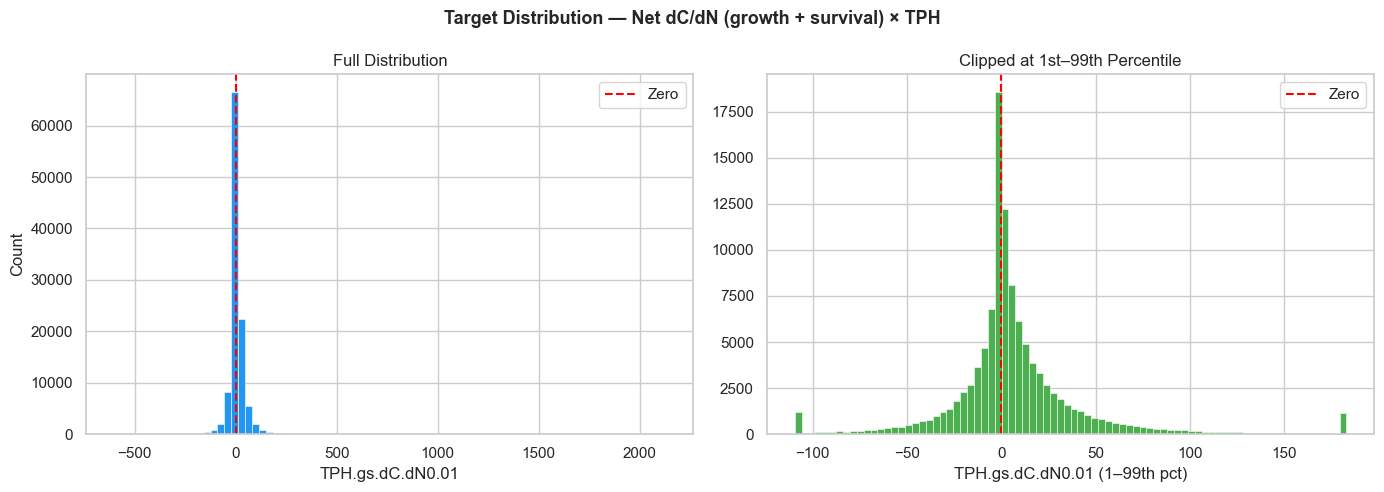

In [4]:
fig = plot_target_distribution(df, save=True)
plt.show()

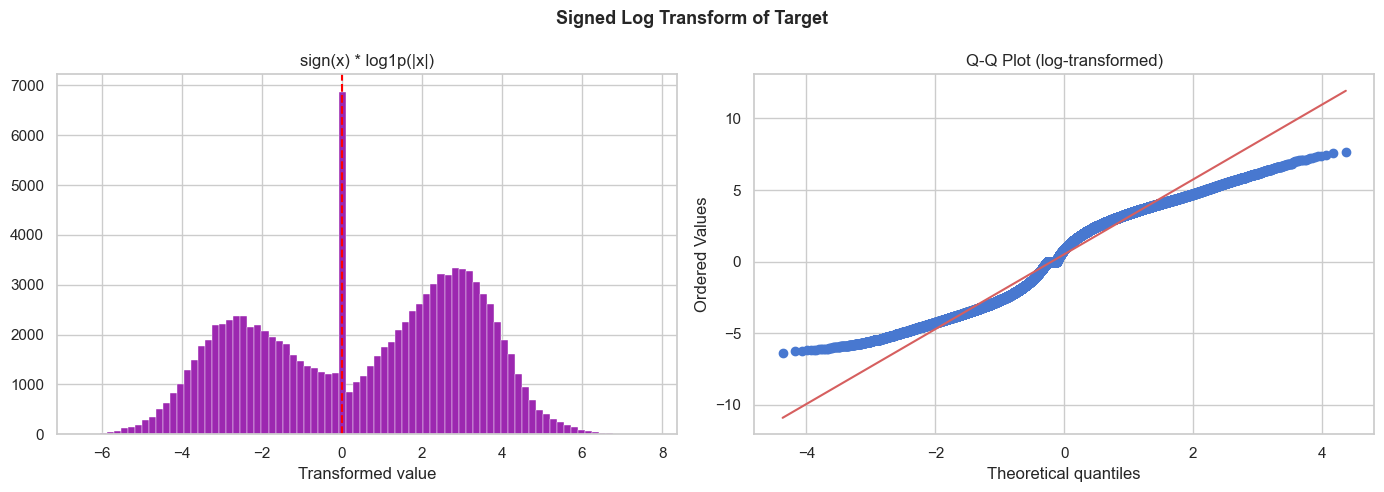

In [5]:
# Log-transformed view to inspect tails
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Signed Log Transform of Target', fontsize=13, fontweight='bold')

log_target = np.sign(df[TARGET]) * np.log1p(np.abs(df[TARGET]))

axes[0].hist(log_target.dropna(), bins=80, color='#9C27B0', edgecolor='white', lw=0.3)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_title('sign(x) * log1p(|x|)')
axes[0].set_xlabel('Transformed value')

from scipy import stats
stats.probplot(log_target.dropna(), plot=axes[1])
axes[1].set_title('Q-Q Plot (log-transformed)')

plt.tight_layout()
plt.savefig('outputs/figures/02a_log_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Missing Value Analysis

  💾 Saved: outputs\figures\02_missing_values.png


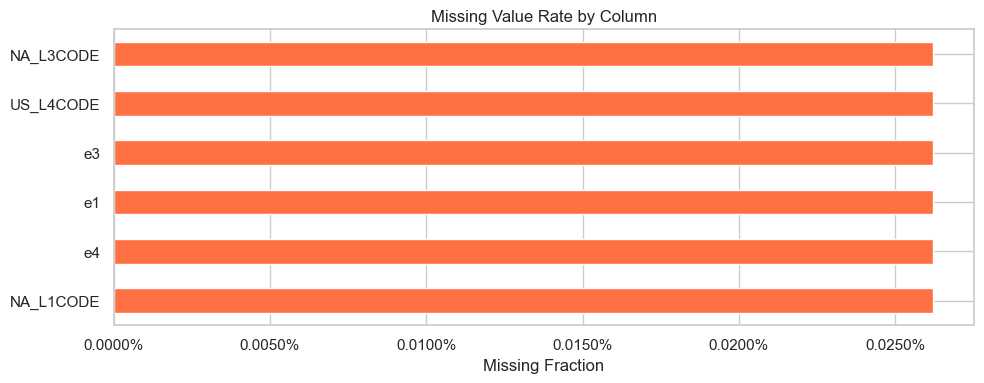

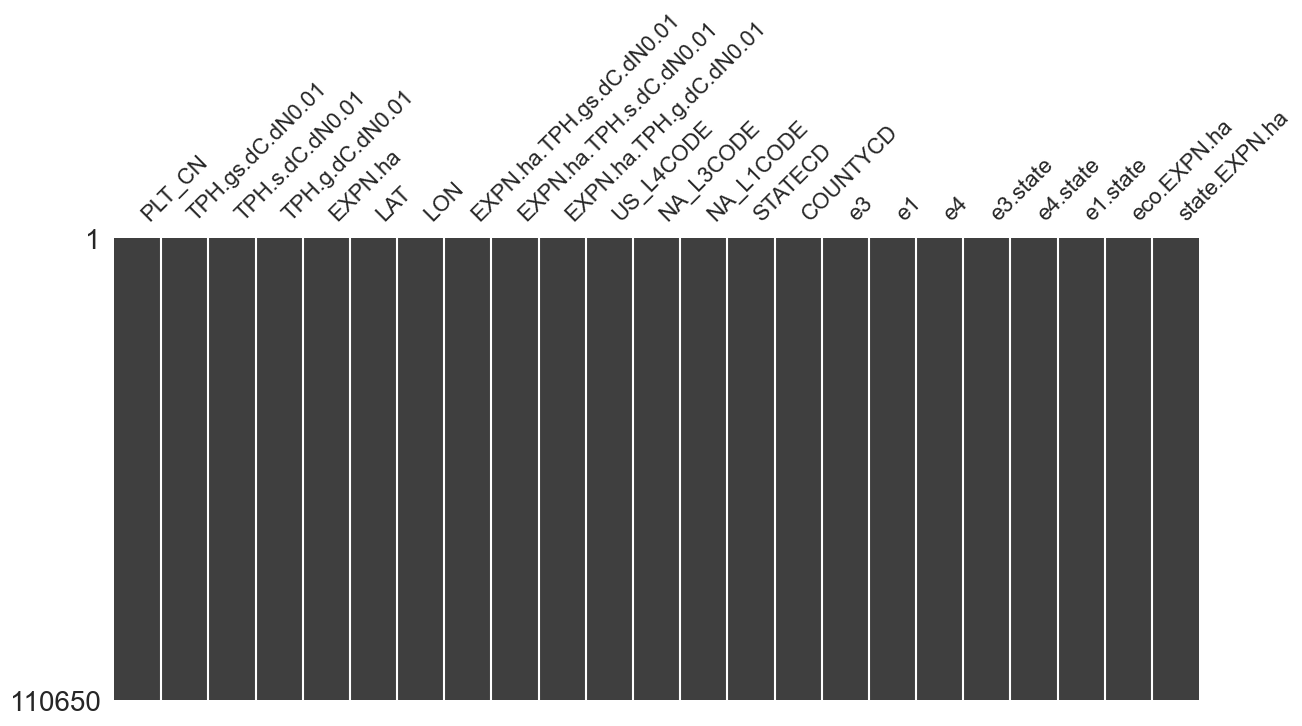

In [6]:
fig = plot_missing_values(df, save=True)
if fig: plt.show()

# Heatmap of missingness co-occurrence
try:
    import missingno as msno
    msno.matrix(df, figsize=(14, 6), sparkline=False)
    plt.savefig('outputs/figures/02b_missingno_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()
except ImportError:
    print('missingno not installed — skipping matrix plot')

## 4 · Outlier Detection

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# IQR-based outlier count per column
outlier_summary = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    outlier_summary.append({'column': col, 'outlier_count': n_out,
                             'outlier_pct': round(n_out/len(df)*100, 2)})

out_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)
display(out_df.head(15))

,column,outlier_count,outlier_pct
3,EXPN.ha,26604,24.0400
6,EXPN.ha.TPH.gs.dC.dN0.01,17537,15.8500
0,TPH.gs.dC.dN0.01,15843,14.3200
7,EXPN.ha.TPH.s.dC.dN0.01,11938,10.7900
1,TPH.s.dC.dN0.01,11061,10.0000
8,EXPN.ha.TPH.g.dC.dN0.01,9487,8.5700
2,TPH.g.dC.dN0.01,8412,7.6000
11,COUNTYCD,3719,3.3600
13,e1.state,1046,0.9500
12,e1,1046,0.9500


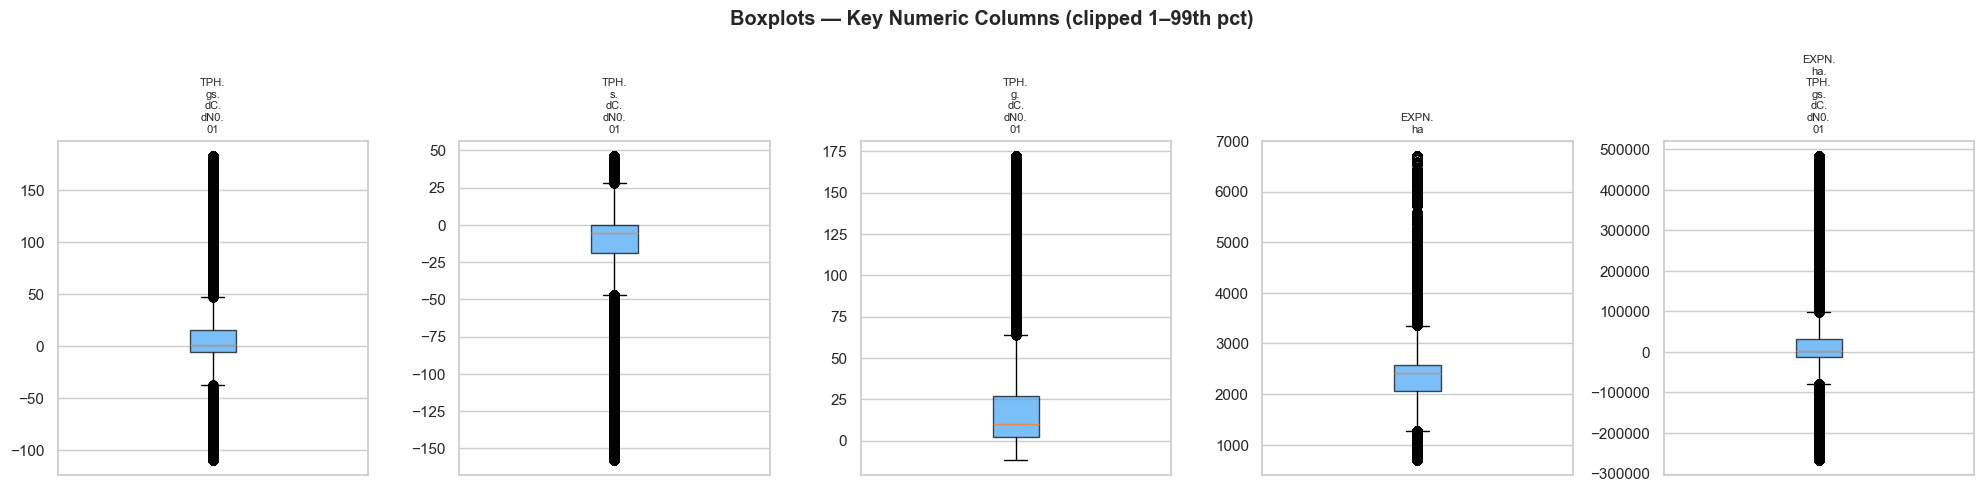

In [8]:
# Box plots for key numeric columns
key_cols = [TARGET, 'TPH.s.dC.dN0.01', 'TPH.g.dC.dN0.01',
            'EXPN.ha', 'EXPN.ha.TPH.gs.dC.dN0.01']
key_cols = [c for c in key_cols if c in df.columns]

fig, axes = plt.subplots(1, len(key_cols), figsize=(4*len(key_cols), 5))
for ax, col in zip(axes, key_cols):
    clipped = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
    ax.boxplot(clipped.dropna(), patch_artist=True,
               boxprops={'facecolor':'#42A5F5','alpha':0.7})
    ax.set_title(col.replace('.','.\n'), fontsize=8)
    ax.set_xticks([])

fig.suptitle('Boxplots — Key Numeric Columns (clipped 1–99th pct)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02c_boxplots_key_cols.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Spatial Distribution

  💾 Saved: outputs\figures\03_spatial_distribution.png


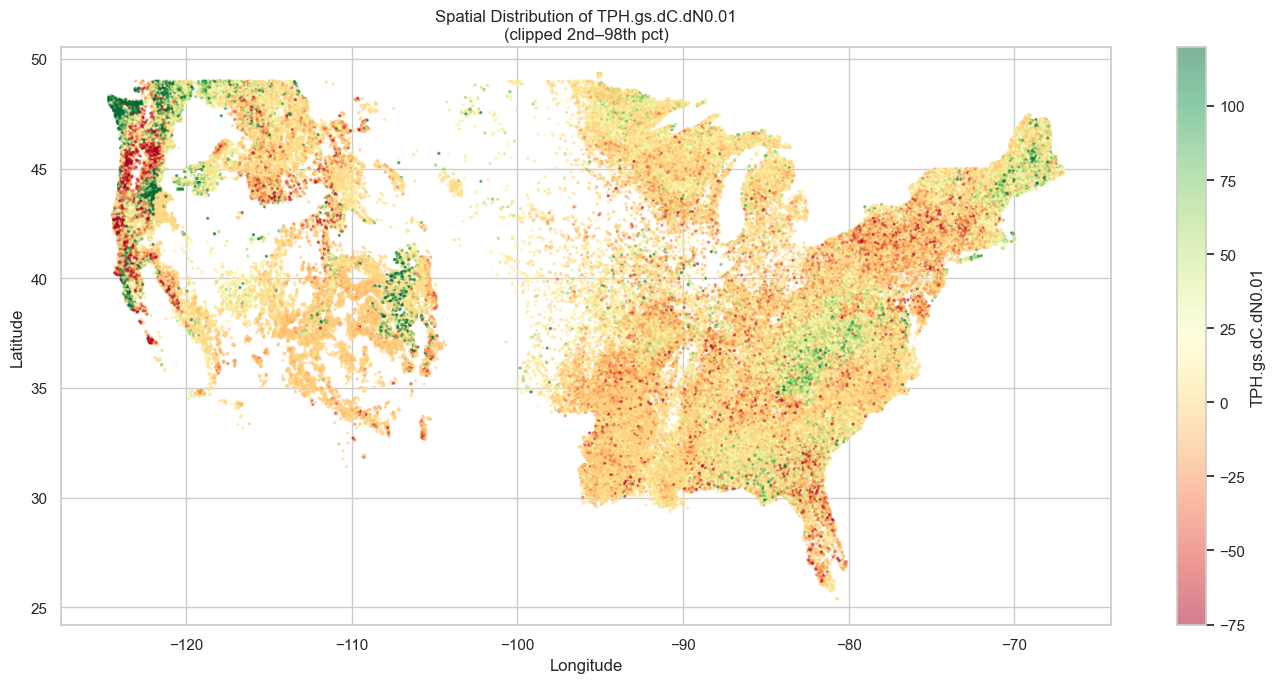

In [9]:
fig = plot_spatial_distribution(df, col=TARGET, save=True)
plt.show()

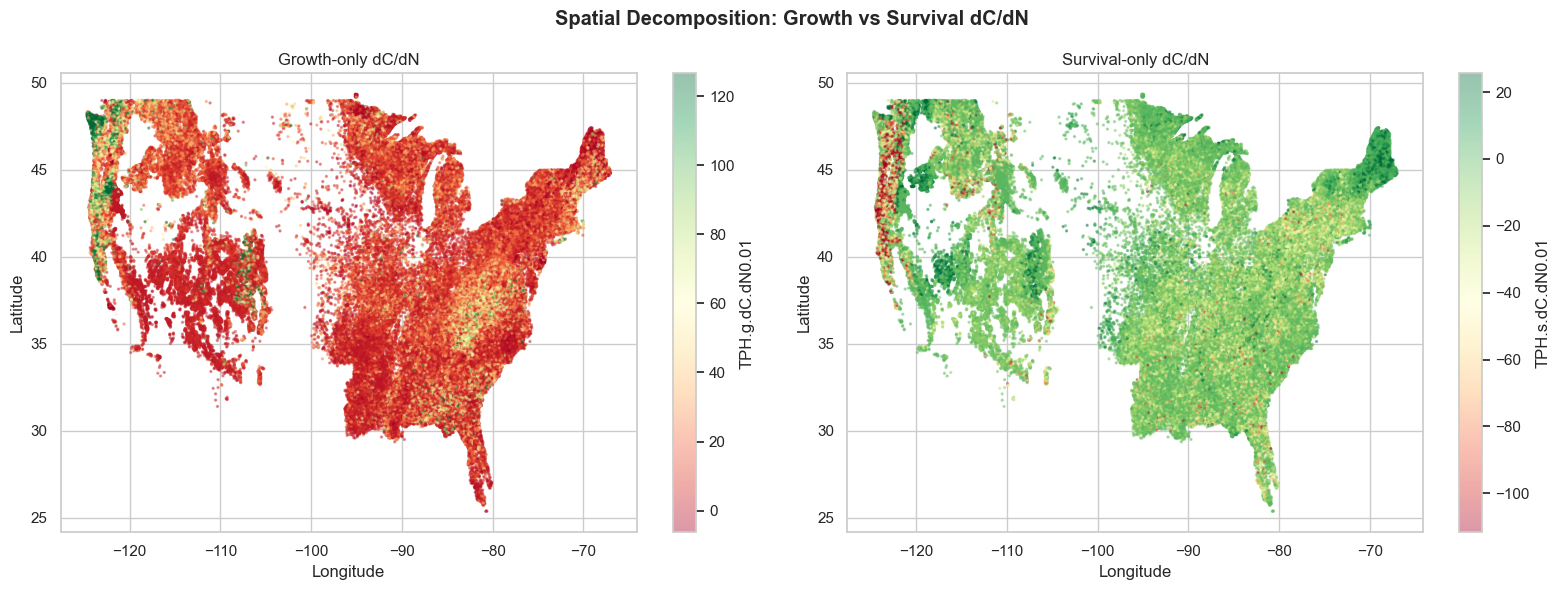

In [10]:
# Compare growth-only vs survival-only spatial signal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
components = [('TPH.g.dC.dN0.01','Growth-only dC/dN'),
              ('TPH.s.dC.dN0.01','Survival-only dC/dN')]

for ax, (col, title) in zip(axes, components):
    if col not in df.columns: continue
    vmin, vmax = df[col].quantile(0.02), df[col].quantile(0.98)
    sc = ax.scatter(df['LON'], df['LAT'], c=df[col].clip(vmin,vmax),
                    cmap='RdYlGn', s=2, alpha=0.4)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

fig.suptitle('Spatial Decomposition: Growth vs Survival dC/dN', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03b_spatial_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Ecoregion Analysis

  💾 Saved: outputs\figures\04_boxplot_NA_L1CODE.png


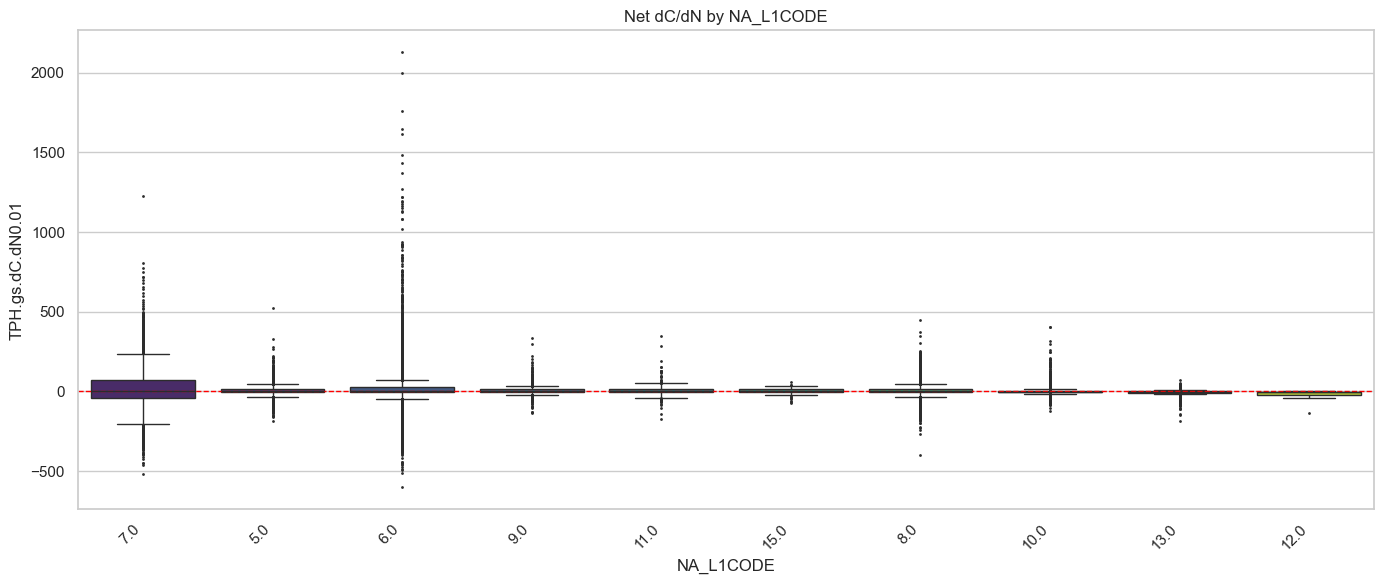

In [11]:
# L1 ecoregion overview
fig = plot_ecoregion_boxplot(df, group_col='NA_L1CODE', save=True)
plt.show()

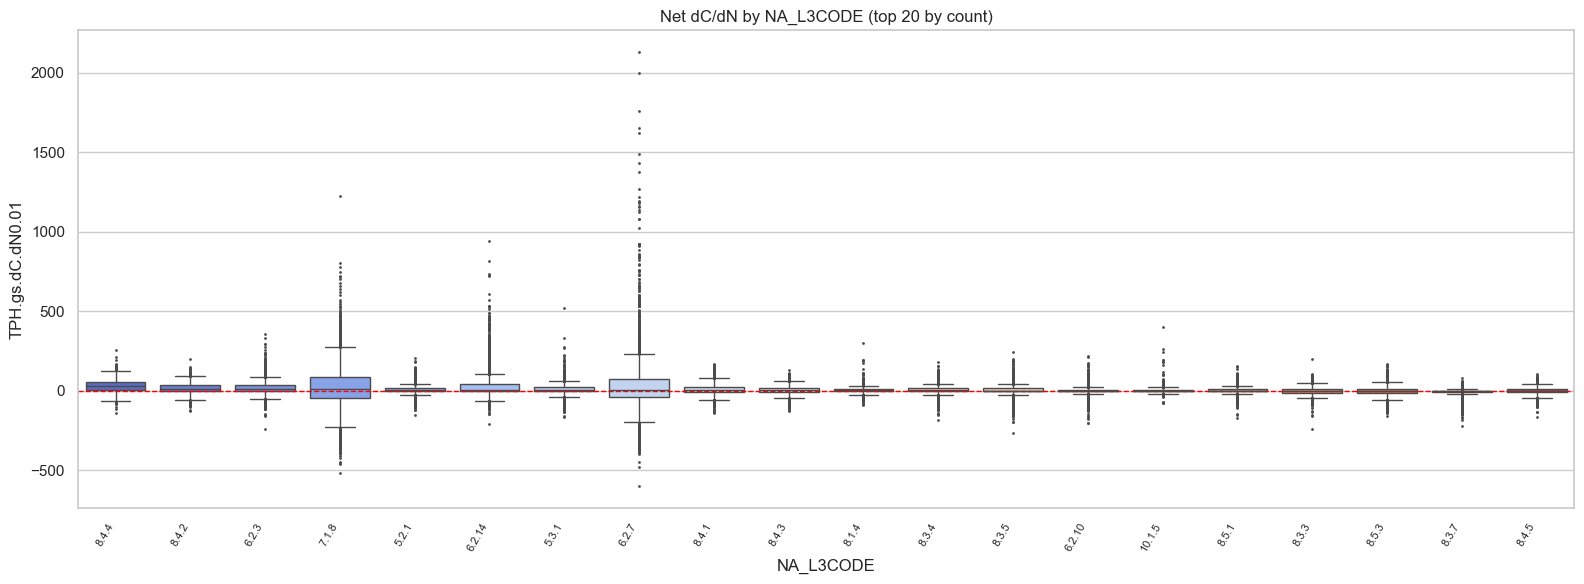

In [12]:
# L3 ecoregion — top 20 by count
top_l3 = df['NA_L3CODE'].value_counts().head(20).index
df_l3 = df[df['NA_L3CODE'].isin(top_l3)]

order = df_l3.groupby('NA_L3CODE')[TARGET].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=df_l3, x='NA_L3CODE', y=TARGET, order=order,
            palette='coolwarm',
            flierprops={'marker':'.','markersize':2}, ax=ax)
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_title('Net dC/dN by NA_L3CODE (top 20 by count)')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/figures/04b_boxplot_L3.png', dpi=150, bbox_inches='tight')
plt.show()

State-level statistics (sorted by median dC/dN):


,STATECD,median,mean,count
44,53,25.7871,47.6620,5224
16,23,17.5660,28.1116,3086
43,51,13.8805,19.8236,3230
31,38,13.6329,21.5991,156
26,33,10.8284,15.1944,1038
36,44,10.6991,13.5510,124
45,54,9.6925,12.3080,2057
13,20,8.1361,11.2477,532
20,27,5.2206,9.9011,5865
39,47,4.8369,8.8107,2845


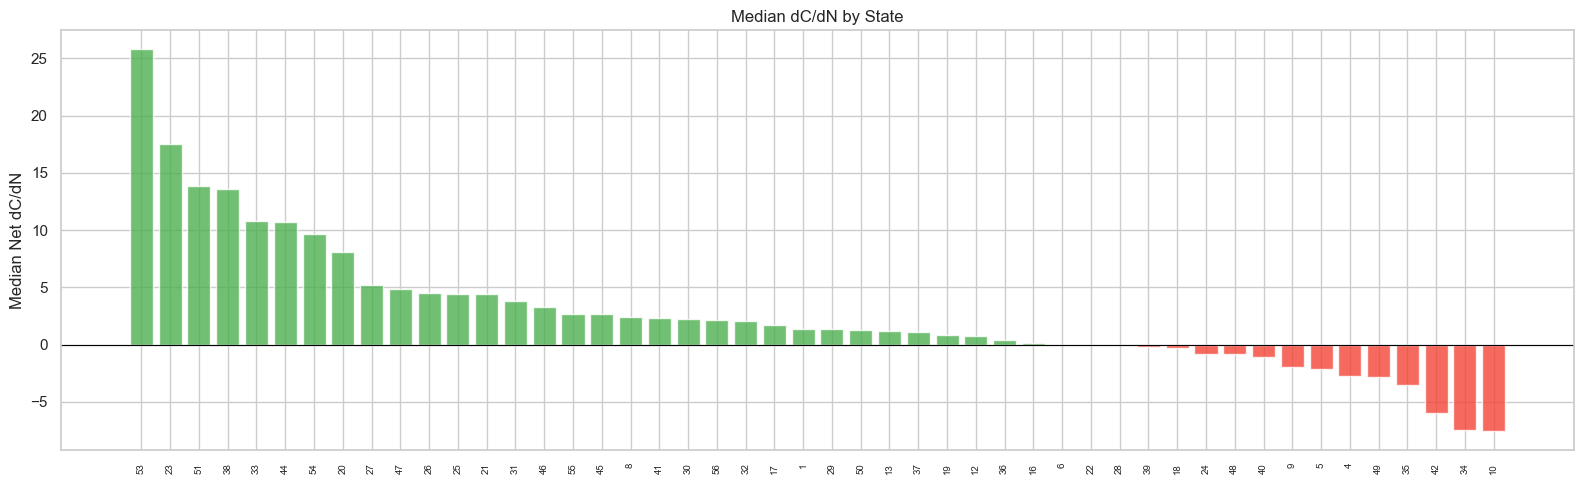

In [13]:
# State-level median dC/dN
state_stats = df.groupby('STATECD')[TARGET].agg(['median','mean','count']).reset_index()
state_stats = state_stats.sort_values('median', ascending=False)
print('State-level statistics (sorted by median dC/dN):')
display(state_stats.head(20))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(state_stats)), state_stats['median'],
       color=np.where(state_stats['median']>0,'#4CAF50','#F44336'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(state_stats)))
ax.set_xticklabels(state_stats['STATECD'], rotation=90, fontsize=7)
ax.set_ylabel('Median Net dC/dN'); ax.set_title('Median dC/dN by State')
plt.tight_layout()
plt.savefig('outputs/figures/04c_state_median.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Correlation Analysis

  💾 Saved: outputs\figures\05_correlation_heatmap.png


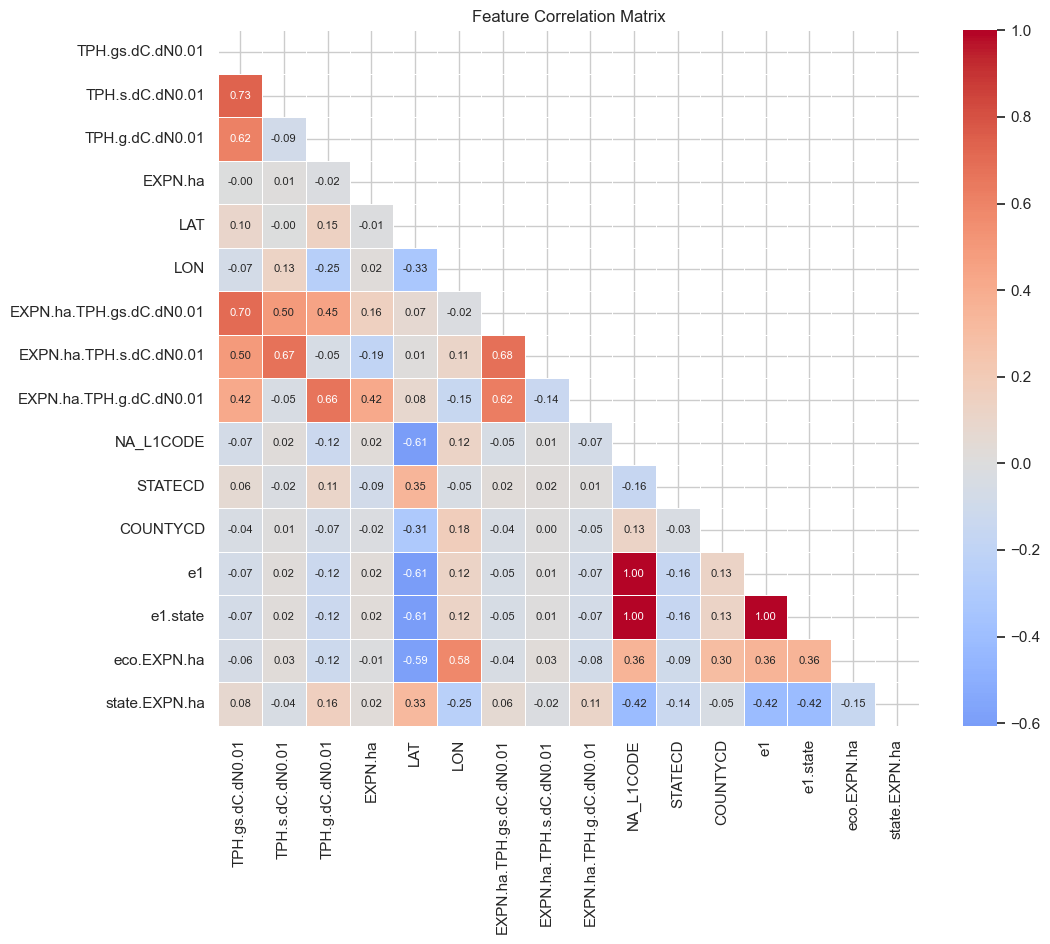

In [14]:
num_df = df.select_dtypes(include=np.number)
fig = plot_correlation_heatmap(df, cols=num_df.columns.tolist(), save=True)
plt.show()

Top correlations with target:


,correlation_with_target
TPH.s.dC.dN0.01,0.7319
EXPN.ha.TPH.gs.dC.dN0.01,0.6996
TPH.g.dC.dN0.01,0.6157
EXPN.ha.TPH.s.dC.dN0.01,0.4960
EXPN.ha.TPH.g.dC.dN0.01,0.4178
LAT,0.0977
state.EXPN.ha,0.0765
e1,-0.0725
NA_L1CODE,-0.0725
e1.state,-0.0724


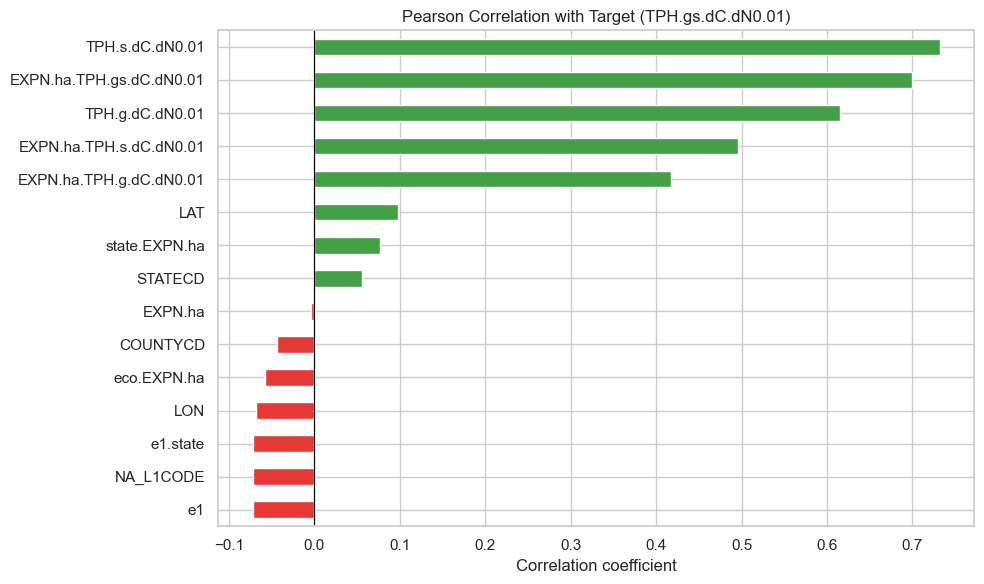

In [15]:
# Correlation with target specifically
corr_with_target = num_df.corrwith(df[TARGET]).drop(TARGET).sort_values(key=abs, ascending=False)
print('Top correlations with target:')
display(corr_with_target.head(15).to_frame(name='correlation_with_target'))

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_target.head(15).sort_values().plot.barh(
    ax=ax, color=np.where(corr_with_target.head(15).sort_values()>0,'#43A047','#E53935'))
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pearson Correlation with Target (TPH.gs.dC.dN0.01)')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('outputs/figures/05b_target_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Pairplot — Core Variables

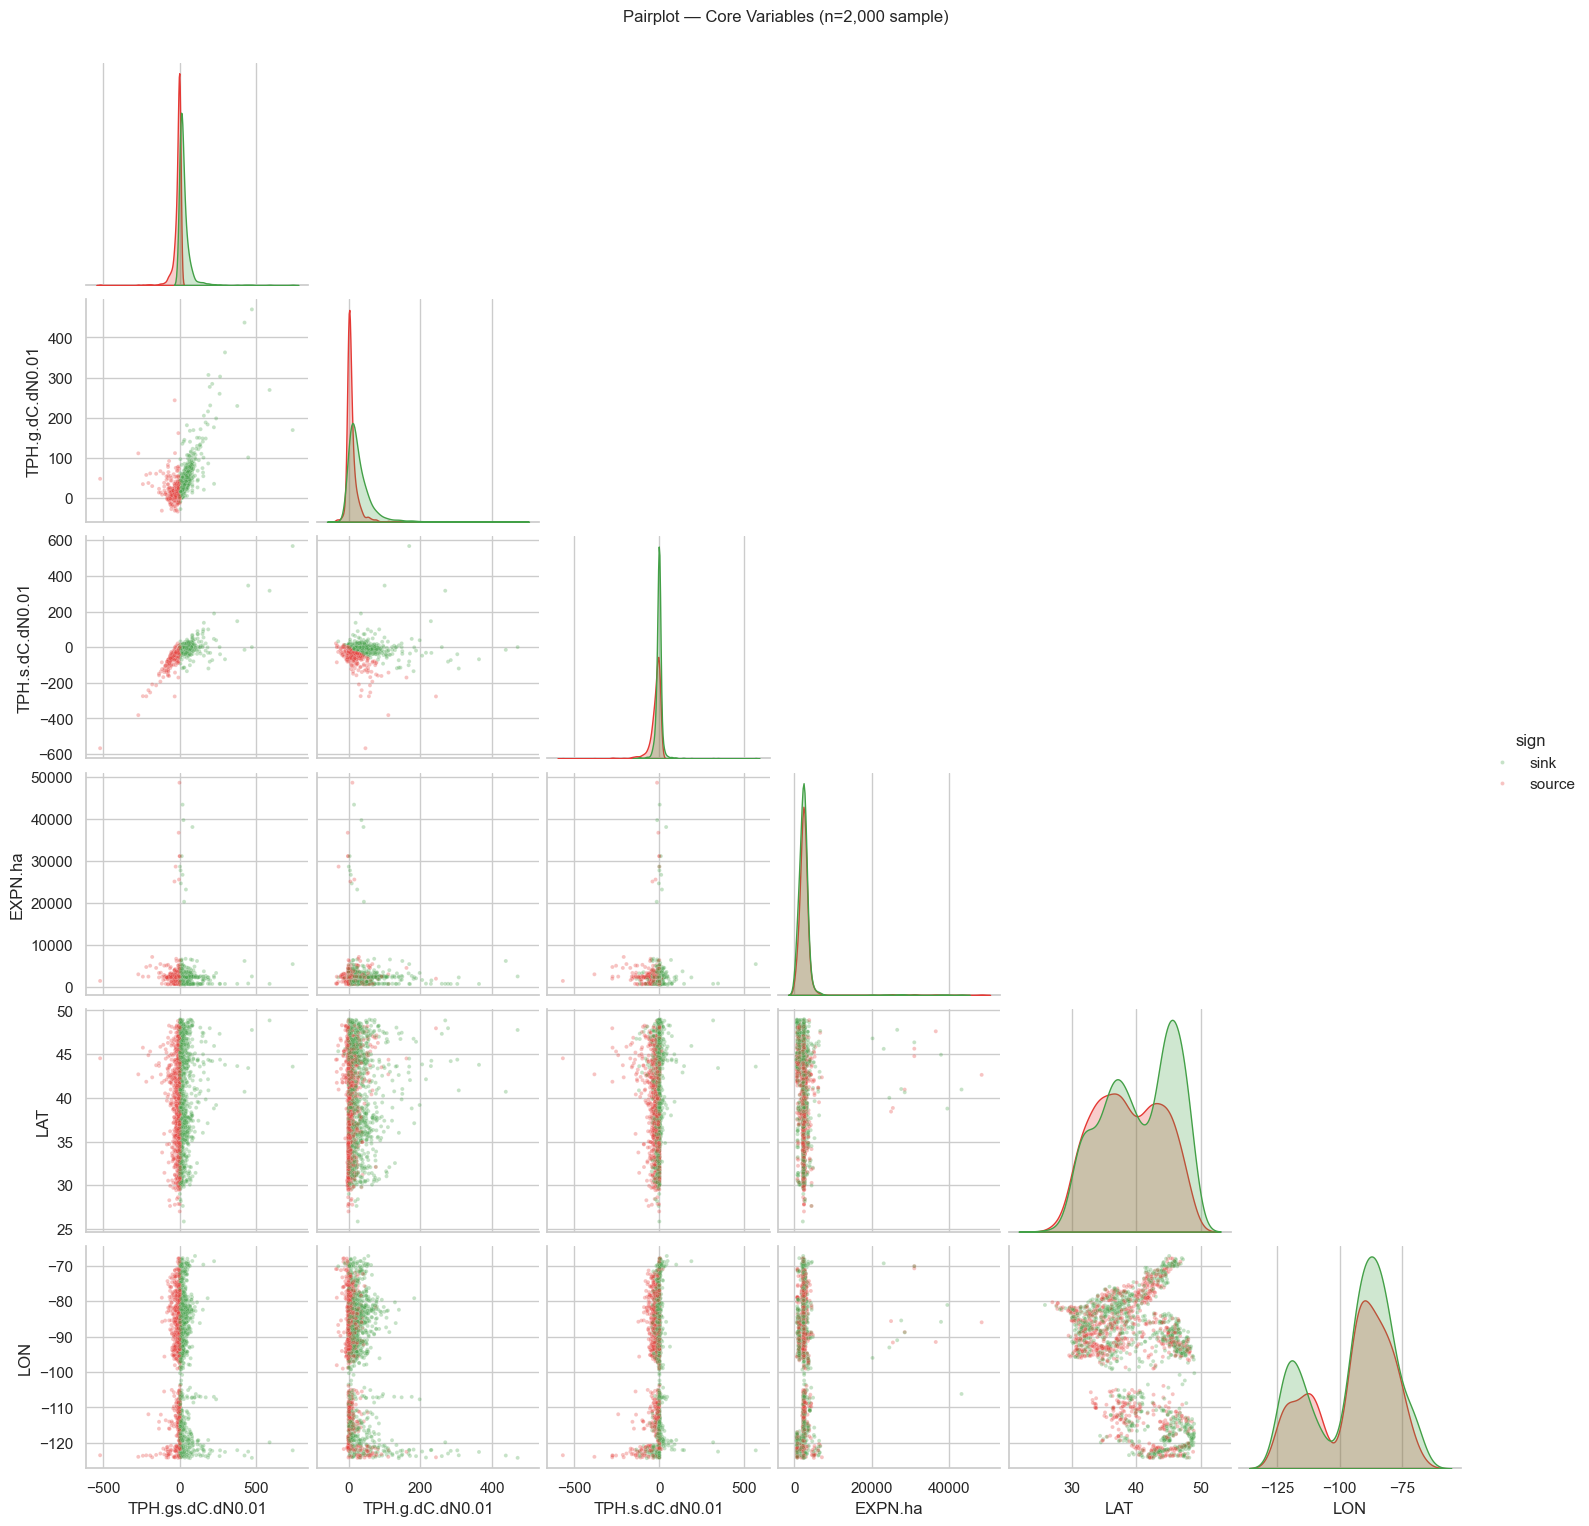

In [16]:
core = [TARGET, 'TPH.g.dC.dN0.01', 'TPH.s.dC.dN0.01', 'EXPN.ha', 'LAT', 'LON']
core = [c for c in core if c in df.columns]

sample = df[core].dropna().sample(min(2000, len(df)), random_state=42)
sample['sign'] = (sample[TARGET] > 0).map({True:'sink', False:'source'})

fig = sns.pairplot(sample, hue='sign', vars=core, plot_kws={'alpha':0.3,'s':8},
                   palette={'sink':'#43A047','source':'#E53935'},
                   diag_kind='kde', corner=True)
fig.figure.suptitle('Pairplot — Core Variables (n=2,000 sample)', y=1.02, fontsize=12)
plt.savefig('outputs/figures/06_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 · Expansion Factor Analysis

Expansion factor (EXPN.ha) statistics:
count   110650.0000
mean      2526.0148
std       2902.5911
min        391.7343
25%       2052.3153
50%       2407.4616
75%       2573.3817
max      67463.7055
Name: EXPN.ha, dtype: float64


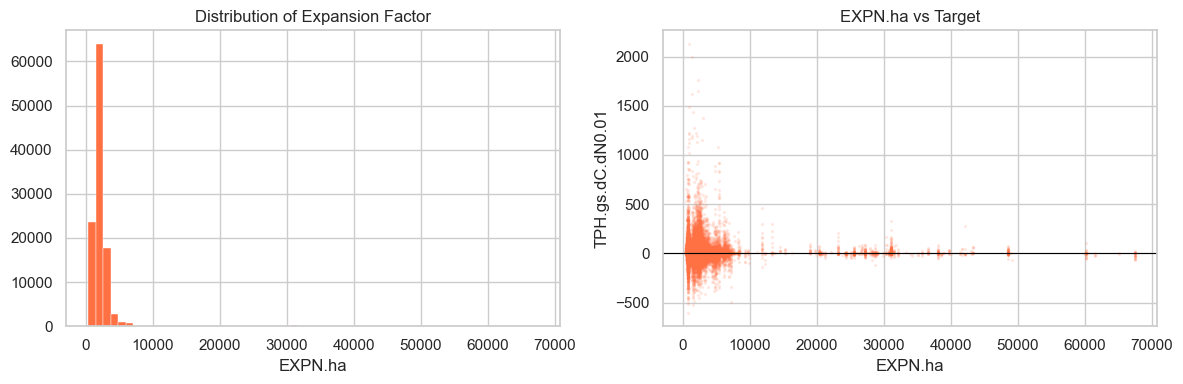

In [17]:
print('Expansion factor (EXPN.ha) statistics:')
print(df['EXPN.ha'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['EXPN.ha'].dropna(), bins=60, color='#FF7043', edgecolor='white', lw=0.3)
axes[0].set_xlabel('EXPN.ha'); axes[0].set_title('Distribution of Expansion Factor')

axes[1].scatter(df['EXPN.ha'], df[TARGET], alpha=0.1, s=2, c='#FF7043')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('EXPN.ha'); axes[1].set_ylabel(TARGET)
axes[1].set_title('EXPN.ha vs Target')

plt.tight_layout()
plt.savefig('outputs/figures/07_expansion_factor.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 · Key Findings Summary

In [18]:
print('=== EDA Key Findings ===')
print(f'Total FIA plots         : {len(df):,}')
print(f'Carbon sinks (dC/dN > 0): {(df[TARGET]>0).sum():,} ({(df[TARGET]>0).mean()*100:.1f}%)')
print(f'Carbon sources          : {(df[TARGET]<0).sum():,} ({(df[TARGET]<0).mean()*100:.1f}%)')
print(f'Median dC/dN            : {df[TARGET].median():.4f}')
print(f'Target skewness         : {df[TARGET].skew():.3f}  (|>1| = highly skewed)')
print(f'States represented      : {df["STATECD"].nunique()}')
print(f'L1 ecoregions           : {df["NA_L1CODE"].nunique()}')
print(f'L3 ecoregions           : {df["NA_L3CODE"].nunique()}')
print(f'L4 ecoregions           : {df["US_L4CODE"].nunique()}')
print()
print('Preprocessing priorities identified:')
print('  1. Handle extreme outliers in target (heavy tails)')
print('  2. Encode categorical ecoregion codes')
print('  3. Consider log/signed-log transform of target for regression models')
print('  4. Weight samples by EXPN.ha (expansion factor) where supported')

=== EDA Key Findings ===
Total FIA plots         : 110,650
Carbon sinks (dC/dN > 0): 60,647 (54.8%)
Carbon sources          : 44,010 (39.8%)
Median dC/dN            : 1.3699
Target skewness         : 6.563  (|>1| = highly skewed)
States represented      : 48
L1 ecoregions           : 10
L3 ecoregions           : 81
L4 ecoregions           : 778

Preprocessing priorities identified:
  1. Handle extreme outliers in target (heavy tails)
  2. Encode categorical ecoregion codes
  3. Consider log/signed-log transform of target for regression models
  4. Weight samples by EXPN.ha (expansion factor) where supported


---
### ✅ Notebook 02 Complete
Next: **03_preprocessing.ipynb**